In [1]:
#Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder

#To suppress all warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
path = "student-por.csv"
df1 = pd.read_csv(path, sep = ";")

In [3]:
df1.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df1.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [5]:
df1.isna().sum()
# Checking for missing values.

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
df1.shape

(649, 33)

In [7]:
df1 = df1.drop_duplicates()

In [8]:
df1.shape # As we see, dataset has no duplicates, because the number of rows didnt change

(649, 33)

In [9]:
df1.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [10]:
df1.describe() # Basic statistic of numerical features in dataset(include outliers, mean values, etc.)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [11]:
df1.describe(include="O") # Basic statistic of categorical/binary features in dataset(include outliers, mean values, etc.)

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


## This dataset provides information about students who passed "Postuguese language" subject in two Portuguese schools. As we see, dataset has 33 columns and 649 rows. There is no missing values and duplicated rows in this dataset. We are predicting a G3(final grade of student) which is a target attribute.

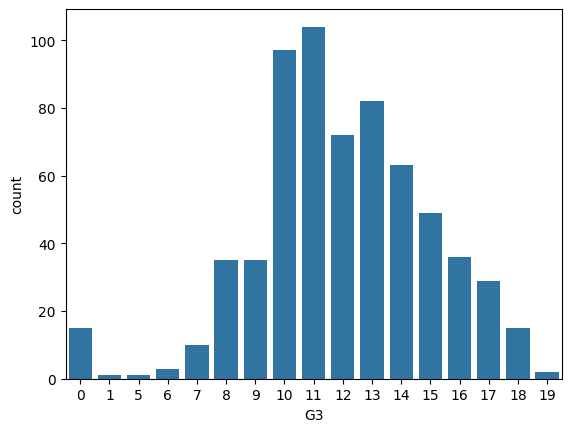

In [12]:
sns.countplot(x='G3', data=df1)
plt.show()

### Most student's final grade is between 10 and 15.

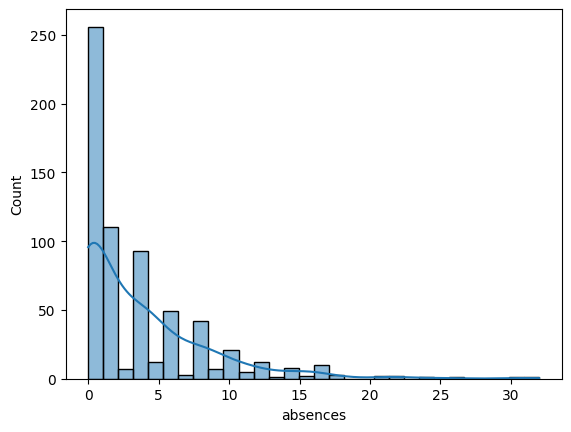

In [13]:
sns.histplot(df1["absences"], kde=True, bins=30)
plt.show()

### Most students have 0 absences.

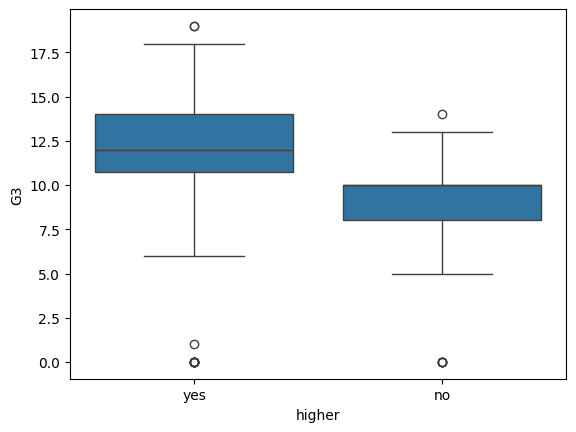

In [14]:
sns.boxplot(x='higher', y='G3', data=df1)
plt.show()

### Students who want to take higher education have better final grade in average. Hence, this feature is very important. Next plot proves it

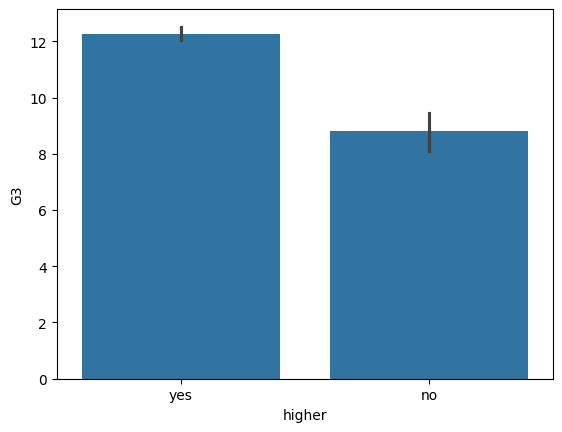

In [15]:
sns.barplot(x='higher', y="G3", data=df1)
plt.show()

### We can see significant difference of average final grade between students who DO want to take higher education and DONT

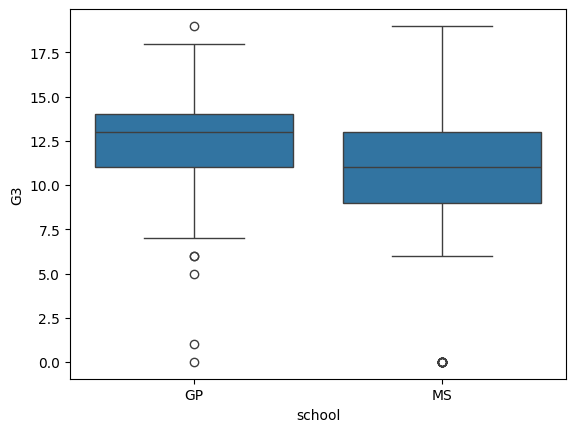

In [16]:
sns.boxplot(x='school', y='G3', data=df1)
plt.show()

### Gabriel Pereira (GP) students: Box shape is thiner. Hence, 50% of grades lies on small range.
### Mousinho da Silveira (MS) students: Box shape is thicker. Hence, 50% of grades lies on bigger range. However, lower than GP box
### We can conclude that, in average, Students from school of Gabriel Pereira (GP) have better final grade than students from Mousinho da Silveira (MS).

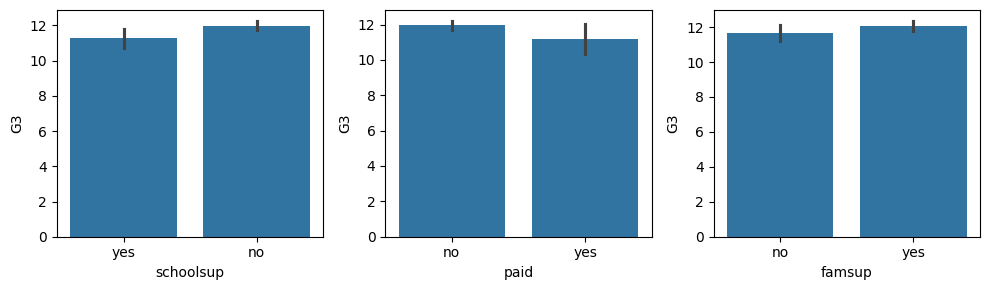

In [17]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.barplot(x='schoolsup', y="G3", data=df1)

plt.subplot(1, 3, 2)
sns.barplot(x='paid', y="G3", data=df1)

plt.subplot(1, 3, 3)
sns.barplot(x='famsup', y="G3", data=df1)

plt.tight_layout()

plt.show()

### Our thoughts that school support, paid(extra classes) and family support are important for final grade became wrong.

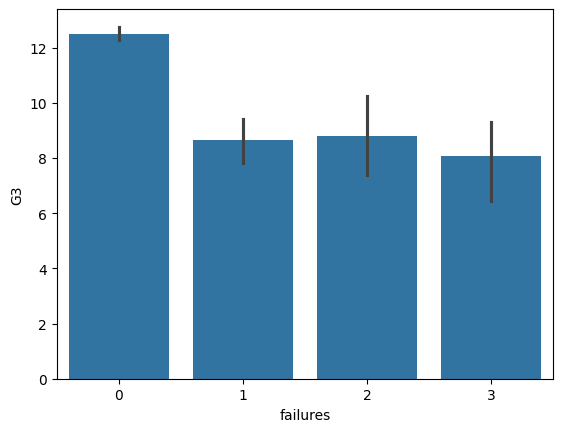

In [18]:
sns.barplot(x='failures', y="G3", data=df1)
plt.show()

### Students with zero failures have better average final grades

<Axes: >

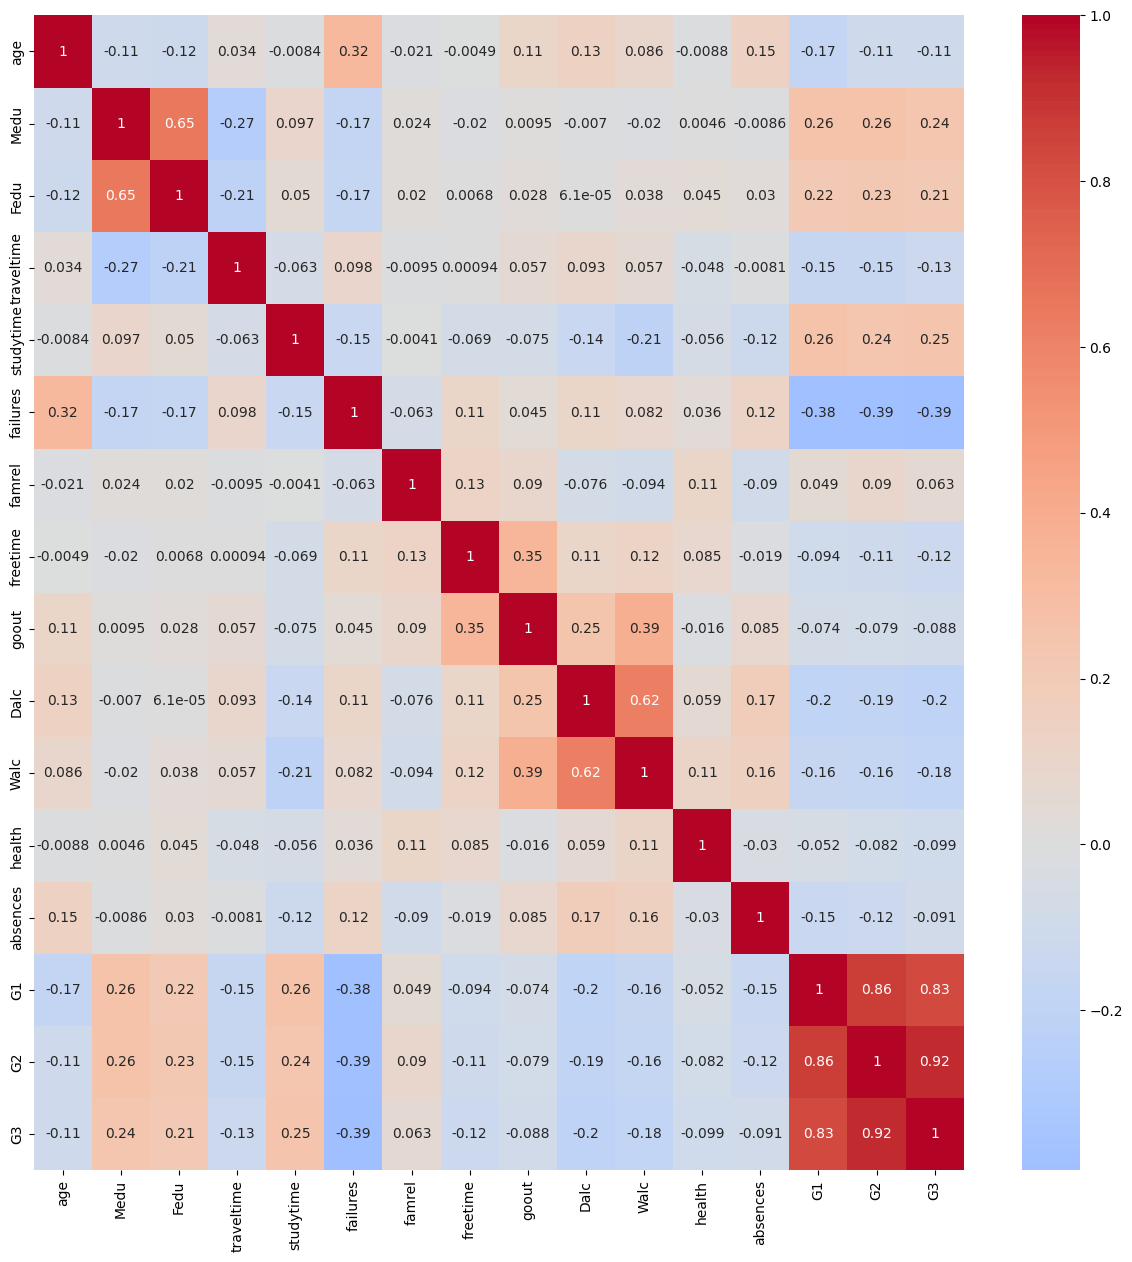

In [19]:
plt.figure(figsize=(15, 15))
sns.heatmap(df1.select_dtypes(include=["number"]).corr(), annot=True, cmap="coolwarm", center=0)

### The most significant features are G1 and G2(period grades). There is also strong positive correlation with Mother/Father education and studying time. In other hand, there is strong negative correlation with failures and alcohol consumption(Weekends/Weekdays). Both strong positive and negative correlations are useful for us

In [20]:
df1 = df1.drop(columns=["age", "famrel", "freetime", "goout", "health", "absences", "traveltime"])
# Dropping numerical columns with weak correlation

### We checked numerical features, now we should check categorical features for correlation with G3

In [21]:
# just compared label encoding and encoding by myself(just skip this part)
# Changing binary dtypes into numeric
# df3 = pd.DataFrame()
# df3["famsize_num"]=df1["famsize"].map({"LE3": 0, "GT3": 1})
# df3["Pstatus_num"]=df1["Pstatus"].map({"A": 0, "T": 1})
# df3["Mjob_num"]=df1["Mjob"].apply(lambda x: 0 if x=="at_home" else 1)
# df3["Fjob_num"]=df1["Fjob"].apply(lambda x: 0 if x=="at_home" else 1)
# df3["schoolsup_num"]=df1["schoolsup"].map({"no": 0, "yes": 1})
# df3["famsup_num"]=df1["famsup"].map({"no": 0, "yes": 1})
# df3["paid_num"]=df1["paid"].map({"no": 0, "yes": 1})
# df3["activities_num"]=df1["activities"].map({"no": 0, "yes": 1})
# df3["nursery_num"]=df1["nursery"].map({"no": 0, "yes": 1})
# df3["higher_num"]=df1["higher"].map({"no": 0, "yes": 1})
# df3["internet_num"]=df1["internet"].map({"no": 0, "yes": 1})
# df3["address_num"]=df1["address"].map({"R": 0, "U": 1})
# df3["school_num"]=df1["school"].map({"GP": 0, "MS": 1})
# df3["sex_num"]=df1["sex"].map({"F": 0, "M": 1})
# df3["reason_num"]=df1["reason"].apply(lambda x: 0 if x=="home" or x=="other" else 1)
# df3["guardian_num"]=df1["guardian"].apply(lambda x: 0 if x=="other" else 1)
# df3["romantic_num"]=df1["romantic"].map({"no": 0, "yes": 1})
# df3["G1"]=df1["G1"]
# df3["G2"]=df1["G2"]
# df3["G3"]=df1["G3"]

In [22]:
df3 = pd.DataFrame()
cols = df1.select_dtypes(include=['object']).columns
df3[cols] = df1[cols].apply(LabelEncoder().fit_transform) # Label Encoding to change categorical features into numerical
df3["G1"]=df1["G1"]
df3["G2"]=df1["G2"]
df3["G3"]=df1["G3"]

### Created another DataFrame df3 to select only categorical/binary columns and check correlation with final grade

<Axes: >

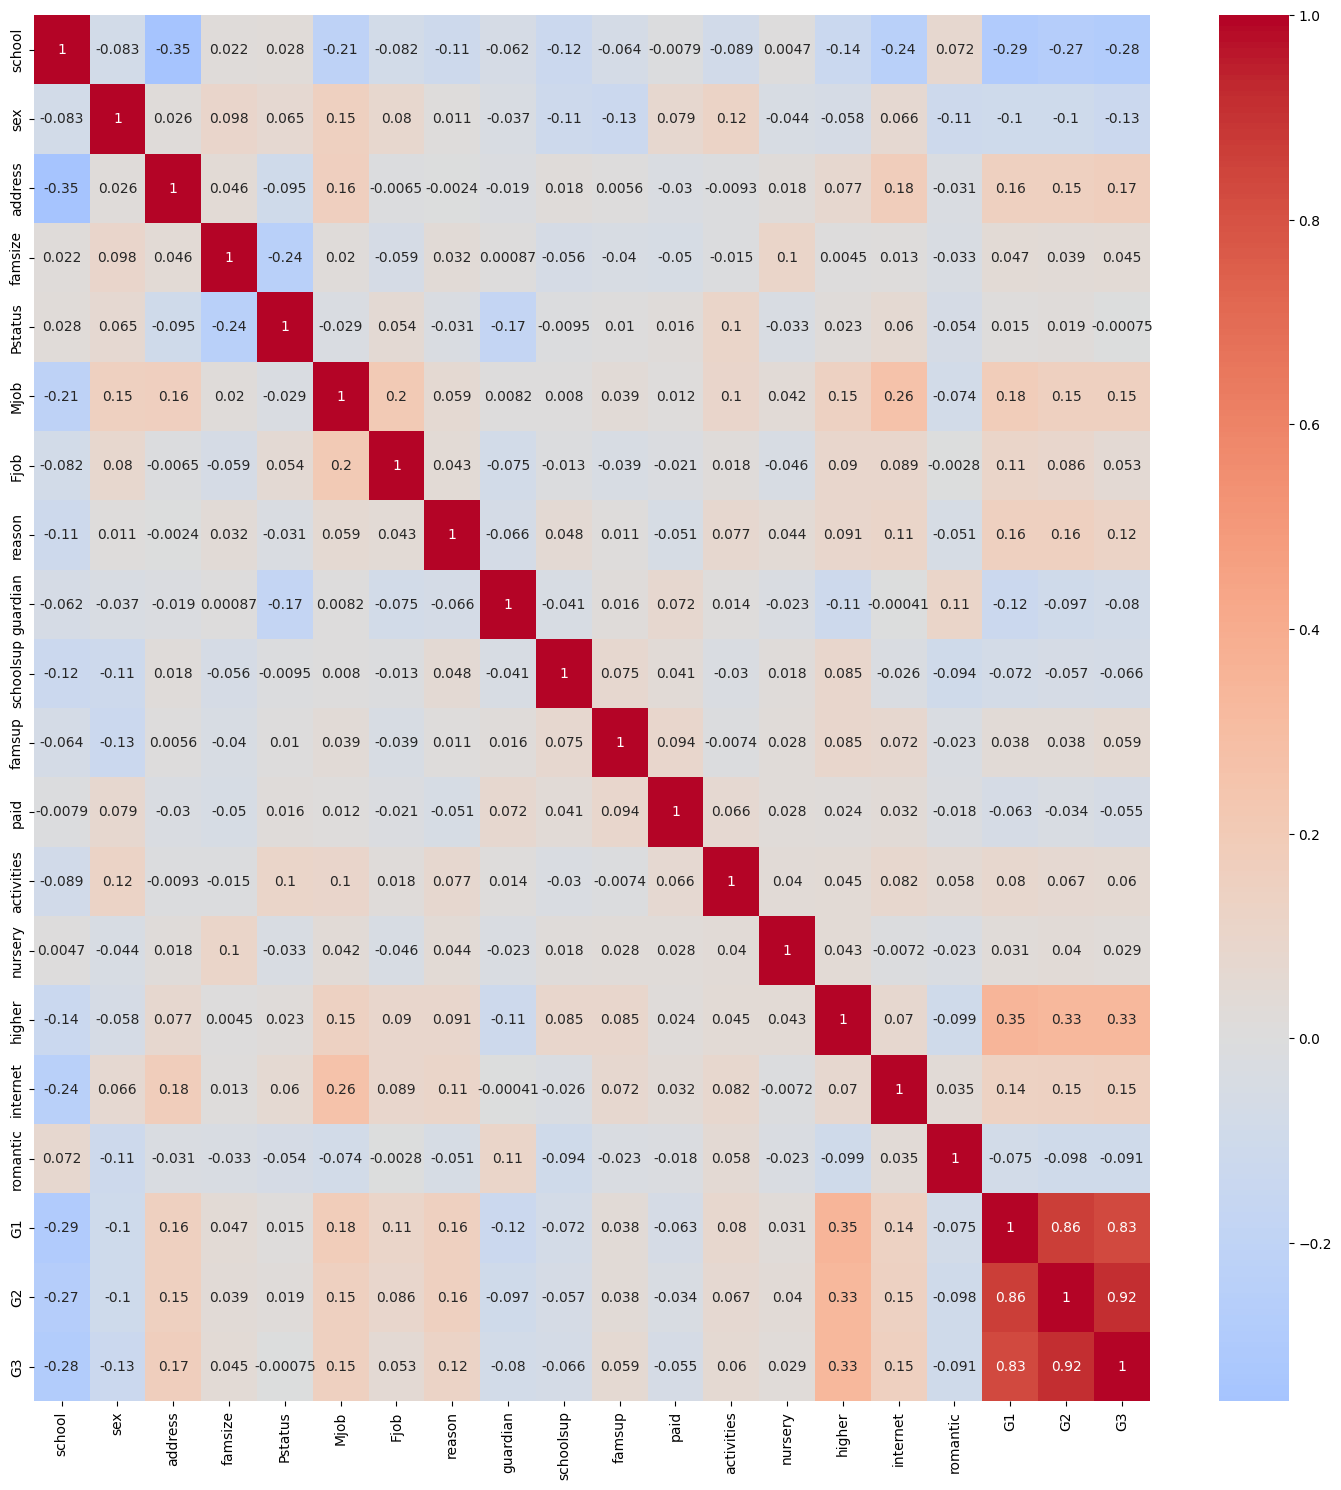

In [23]:
plt.figure(figsize=(18, 18))
sns.heatmap(df3.corr(), annot=True, cmap="coolwarm", center=0)

### Categorical features with strong correlation: school, address, higher. Our conclusions that we made before just have been prooved in this correlation map.(conclusions that students from "Gabriel Pereira" school and students who want to take higher education have better final grades)

In [24]:
df1 = df1.drop(columns=["famsize", "Pstatus", "Mjob", "Fjob", "schoolsup", "famsup", "paid", "activities", "nursery", "internet", "sex", "reason", "guardian", "romantic"])
# dropping categorical columns with weak correlation

In [25]:
cols = df1.select_dtypes(include=['object']).columns
df1[cols] = df1[cols].apply(LabelEncoder().fit_transform)
# Now we can do encoding on original DataFrame(also, a model cannot train on categorical data)

In [26]:
df1.shape

(649, 12)

In [27]:
df1.head() # So, now we have only 11 features 

,school,address,Medu,Fedu,studytime,failures,higher,Dalc,Walc,G1,G2,G3
0,0,1,4,4,2,0,1,1,1,0,11,11
1,0,1,1,1,2,0,1,1,1,9,11,11
2,0,1,1,1,2,0,1,2,3,12,13,12
3,0,1,4,2,3,0,1,1,1,14,14,14
4,0,1,3,3,2,0,1,1,2,11,13,13


In [28]:
df1["academic_history"]=(df1["failures"]>0).astype(int)
df1["motivated_student"]=((df1["failures"]==0) & (df1["studytime"]>2)).astype(int)
# Creating new features

<Axes: >

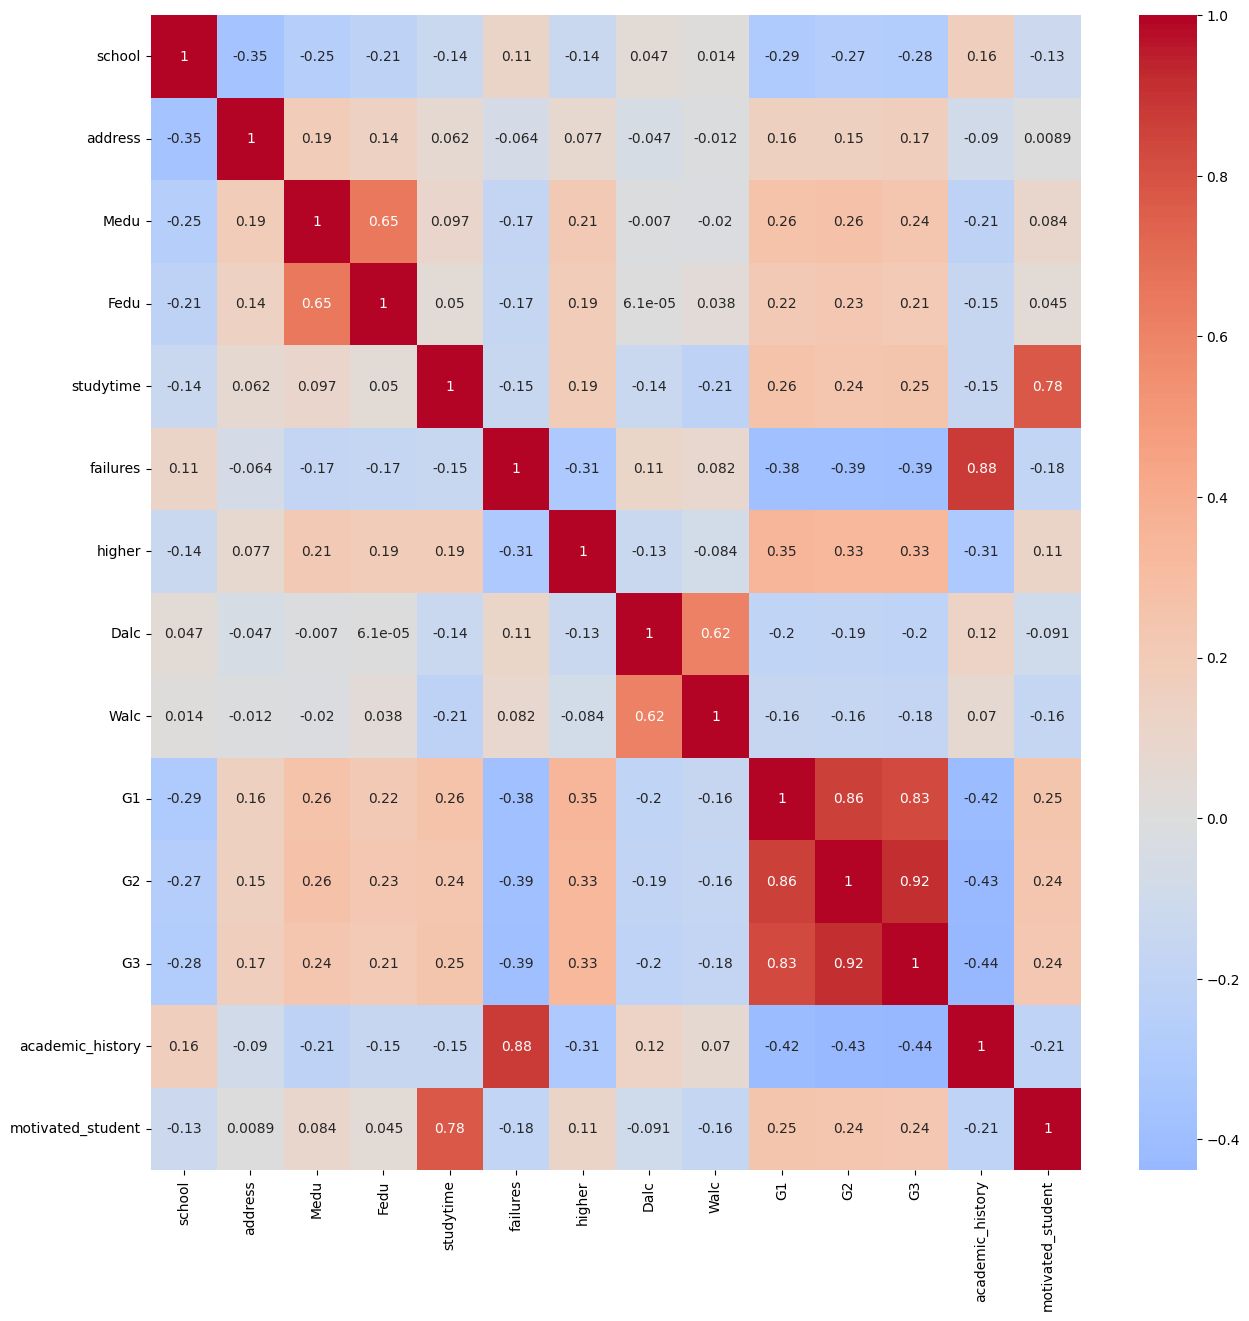

In [29]:
plt.figure(figsize=(15, 15))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm", center=0)

### So, now we have correlation map only with significant features

In [35]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler() # To make features standard normal distributed

In [32]:
X = df1[["school","address","Medu","Fedu","studytime","failures","higher","Dalc","Walc","academic_history","motivated_student","G1","G2"]]
y = df1["G3"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train) # To make features standard normal distributed
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(519, 13)
(130, 13)
(519,)
(130,)


<h1 align="center">Modelling Notebook</h1>

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 3 Models

In [40]:
models = {
    "Linear Regression (Base)": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Evaluation Metrics and Cross-Validation

In [41]:
result = []

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    # RMSE, MAE, R-squared metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Cross Validation
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    result.append({
        "Model": name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R-squared": round(r2, 4),
        "CV Mean (R2)": round(cv_score.mean(), 4),
        "CV Std (R2)": round(cv_score.std(), 4)
    })    

In [42]:
metrics_df = pd.DataFrame(result)
metrics_df

,Model,RMSE,MAE,R-squared,CV Mean (R2),CV Std (R2)
0,Linear Regression (Base),1.1846,0.7336,0.8561,0.8436,0.0467
1,KNN Regressor,1.5647,1.1123,0.7489,0.6642,0.0334
2,Decision Tree,1.7676,0.9321,0.6796,0.8057,0.0558


## Written Interpretation

`Linear Regression` is the best model reaching the highest $R^2$ score (`0.8561`).<br>
`RMSE` of `1.1846` and `MAE` of `0.7336`.<br>
`Cross-Validation` confirms $R^2$ scores with close mean of `0.8436` and low standard deviation of `0.0467` 

## Progress Log